### Handoff

Handoff는 현재 Agent가 다른 Agent에게 대화의 제어권을 넘기는 방식이다. 작업 결과가 중앙 Agent로 돌아가는 Supervisor와 달리, 전환된 Agent가 새로운 담당자가 되어 사용자 요청에 응답하고 이후 대화를 이어간다.

In [1]:
from typing import Literal, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain.agents import create_agent
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from langchain.tools import ToolRuntime, tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.types import Command

load_dotenv()

MODEL_NAME = "gemini-3.6-flash"
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

### Command로 State 변경과 Node 이동

`Command`는 Graph 실행을 제어하기 위한 객체이다. Human-in-the-loop에서는 중단된 Graph에 값을 전달하기 위해 `resume`을 사용했다. 여기서는 Node가 State를 변경하고 다음 실행 위치를 결정하기 위해 `update`와 `goto`를 사용한다.

일반 Node는 딕셔너리를 반환하여 State를 변경하고, 다음 Node는 Edge가 결정한다. `Command`를 사용하면 Node가 State 변경과 다음 실행 위치를 함께 결정할 수 있다.

```python
return Command(
    update={"category": "support"},
    goto="support",
)
```

- `update`: 현재 State에 반영할 값을 지정한다.
- `goto`: 다음에 실행할 Node의 이름을 지정한다.

다음 예제는 문의 내용에 따라 판매 또는 기술 지원 Node로 이동한다.

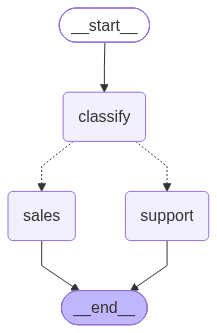

{'query': '제품에서 오류가 발생했어요.',
 'category': 'support',
 'result': '기술 지원 문의로 처리했습니다.'}

In [2]:
class RoutingState(TypedDict):
    query: str
    category: str
    result: str


def classify_query(
    state: RoutingState,
) -> Command[Literal["sales", "support"]]:
    if "오류" in state["query"] or "고장" in state["query"]:
        return Command(
            update={"category": "support"},
            goto="support",
        )

    return Command(
        update={"category": "sales"},
        goto="sales",
    )


def handle_sales(state: RoutingState) -> dict:
    return {"result": "판매 문의로 처리했습니다."}


def handle_support(state: RoutingState) -> dict:
    return {"result": "기술 지원 문의로 처리했습니다."}


routing_builder = StateGraph(RoutingState)
routing_builder.add_node("classify", classify_query)
routing_builder.add_node("sales", handle_sales)
routing_builder.add_node("support", handle_support)

routing_builder.add_edge(START, "classify")
routing_builder.add_edge("sales", END)
routing_builder.add_edge("support", END)

routing_graph = routing_builder.compile()

display(Image(routing_graph.get_graph().draw_mermaid_png()))

routing_graph.invoke({
    "query": "제품에서 오류가 발생했어요.",
    "category": "",
    "result": "",
})

### Edge와 Command

| 상황 | 사용 방식 |
|------|-----------|
| 다음 단계가 항상 동일 | `add_edge()` |
| 작업과 Routing 판단을 분리 | `add_conditional_edges()` |
| State 변경과 이동이 하나의 제어 동작 | `Command(update=..., goto=...)` |

위 예제는 `classify`에서 `sales`나 `support`로 이동하는 Edge를 직접 등록하지 않았다. 실행 중 `classify_query`가 반환하는 `Command`의 `goto`가 다음 Node를 결정한다.

`Command[Literal["sales", "support"]]`의 `Literal`은 가능한 이동 대상을 명시한다. LangGraph는 이 타입 정보를 사용하여 정적 Edge가 없는 동적 이동 후보도 그래프에 표시한다. `Literal`을 생략해도 실행은 가능하지만 시각화 도구는 목적지를 미리 알 수 없다.

> 고정된 흐름과 일반적인 Routing은 Edge로 분리하는 편이 구조를 파악하고 Node를 재사용하기 쉽다. State 변경과 이동이 하나의 제어 동작을 구성할 때는 `Command`를 사용할 수 있다.

### 실습: 문서 검토 상태 전환

문서의 검토 결과에 따라 State를 변경하고 다음 Node로 이동하는 Graph를 구현한다.

- State는 `document`, `approved`, `status`, `result`를 가진다.
- `approved`가 `True`이면 `update`로 `status`를 `approved`로 변경하고 `publish` Node로 이동한다.
- `approved`가 `False`이면 `update`로 `status`를 `revision_required`로 변경하고 `revise` Node로 이동한다.
- `publish`와 `revise` Node는 처리 결과를 `result`에 저장하고 종료한다.
- 완성한 뒤 같은 흐름을 Conditional Edge로 구현한다면 어떤 코드가 분리되는지 비교한다.

In [5]:
class ReviewState(TypedDict):
    document: str
    approved: bool
    status: str
    result: str


def publish_document(state: ReviewState) -> dict:
    return {"result": "문서를 게시했습니다."}


def revise_document(state: ReviewState) -> dict:
    return {"result": "문서를 수정 단계로 보냈습니다."}


# TODO: approved에 따라 status를 변경하고 다음 Node를 선택하는 Node를 정의한다.
def review_document(
    state: ReviewState,
) -> Command[Literal["publish", "revise"]]:
    if state["approved"]:
        return Command(
            update={"status": "approved"},
            goto="publish",
        )

    return Command(
        update={"status": "revision_required"},
        goto="revise",
    )
# TODO: Command의 update와 goto를 사용해 StateGraph를 구성하고 실행한다.
review_builder = StateGraph(ReviewState)

review_builder.add_node("review", review_document)
review_builder.add_node("publish", publish_document)
review_builder.add_node("revise", revise_document)

review_builder.add_edge(START, "review")
review_builder.add_edge("publish", END)
review_builder.add_edge("revise", END)

review_graph = review_builder.compile()


approved_result = review_graph.invoke({
    "document": "검토할 문서입니다.",
    "approved": True,
    "status": "",
    "result": "",
})

revision_result = review_graph.invoke({
    "document": "검토할 문서입니다.",
    "approved": False,
    "status": "",
    "result": "",
})

print("승인 케이스:", approved_result)
print("수정 케이스:", revision_result)

승인 케이스: {'document': '검토할 문서입니다.', 'approved': True, 'status': 'approved', 'result': '문서를 게시했습니다.'}
수정 케이스: {'document': '검토할 문서입니다.', 'approved': False, 'status': 'revision_required', 'result': '문서를 수정 단계로 보냈습니다.'}


### handoff 실습 시나리오

제품 판매 회사의 고객 상담 시스템을 구성한다. 사용자는 Sales Agent와 대화를 시작하며, 문의 내용에 따라 담당 Agent가 바뀔 수 있다.

- Sales Agent: 제품, 가격, 구매 방법에 관한 문의 담당
- Support Agent: 설치, 오류, 고장 등 기술 문의 담당

```text
사용자 → Sales Agent
             └─ 기술 문의 → Support Agent
                                └─ 구매 문의 → Sales Agent
```

현재 Agent가 자신의 담당 범위를 벗어난 요청을 받으면 Handoff Tool을 호출한다. 부모 `StateGraph`는 대화 메시지와 현재 활성 Agent를 State에 저장하고 Agent 사이의 이동을 관리한다.

### Handoff를 수행하는 Tool

다른 Agent로 제어권을 넘기기 위해 호출하는 Tool을 Handoff Tool이라고 한다. 일반 Tool은 실행 결과를 반환하지만, Handoff Tool은 `Command`를 반환하여 담당 Agent를 변경하고 다른 Agent Node로 이동한다.

`graph=Command.PARENT`는 현재 Agent 내부 Graph가 아니라 Agent들을 포함하는 부모 Graph의 Node로 이동하도록 지정한다.

`ToolRuntime`은 Tool 실행 시 LangChain이 자동으로 주입하는 실행 정보이며 모델이 생성하는 Tool 인자가 아니다. Handoff Tool에서는 `runtime.state`로 현재 메시지를 조회하고, `runtime.tool_call_id`로 Tool 호출과 실행 결과를 연결한다.

모델이 Handoff Tool을 호출하면 해당 `AIMessage`는 현재 Agent의 내부 State에 자동으로 추가된다. 그러나 `Command.PARENT`로 내부 Graph를 벗어나면 이 메시지가 부모 Graph의 State에 자동으로 전달되지 않는다. 따라서 내부 State에서 마지막 `AIMessage`를 가져와 Tool 호출을 완료하는 `ToolMessage`와 함께 `Command.update`로 부모 State에 전달한다. 두 메시지의 Tool Call ID를 연결하기 위해 `ToolMessage.tool_call_id`에는 `runtime.tool_call_id`를 사용한다.

In [6]:
def find_last_ai_message(messages: list) -> AIMessage:
    for message in reversed(messages):
        if isinstance(message, AIMessage):
            return message
    raise ValueError("AIMessage를 찾을 수 없습니다.")


@tool
def transfer_to_sales(runtime: ToolRuntime) -> Command:
    """제품, 가격, 구매 문의를 Sales Agent에게 넘긴다."""
    last_ai_message = find_last_ai_message(runtime.state["messages"])
    transfer_message = ToolMessage(
        content="Sales Agent로 전환했습니다.",
        tool_call_id=runtime.tool_call_id,
    )
    return Command(
        goto="sales_agent",
        update={
            "active_agent": "sales_agent",
            "messages": [last_ai_message, transfer_message],
        },
        graph=Command.PARENT,
    )


@tool
def transfer_to_support(runtime: ToolRuntime) -> Command:
    """설치, 오류, 고장 등 기술 문의를 Support Agent에게 넘긴다."""
    last_ai_message = find_last_ai_message(runtime.state["messages"])
    transfer_message = ToolMessage(
        content="Support Agent로 전환했습니다.",
        tool_call_id=runtime.tool_call_id,
    )
    return Command(
        goto="support_agent",
        update={
            "active_agent": "support_agent",
            "messages": [last_ai_message, transfer_message],
        },
        graph=Command.PARENT,
    )

### Agent 구성

각 Agent에는 상대 Agent로 전환하는 Handoff Tool만 제공한다. 자신의 담당 범위에 해당하면 사용자에게 직접 답하고, 담당 범위를 벗어나면 Handoff Tool만 호출한다.

In [7]:
sales_agent = create_agent(
    model=llm,
    tools=[transfer_to_support],
    system_prompt=(
        "너는 제품 판매 상담을 담당하는 Sales Agent다. "
        "대화 기록에서 최신 사용자 요청의 주된 의도를 확인해. "
        "제품 정보, 가격, 구매 방법에 관한 문의라면 사용자에게 직접 답해. "
        "설치, 오류, 고장 등 기술 지원이 필요한 문의라면 직접 답하지 말고 "
        "transfer_to_support만 호출해. Handoff Tool은 한 번에 하나만 호출해."
    ),
    name="sales_agent",
)

support_agent = create_agent(
    model=llm,
    tools=[transfer_to_sales],
    system_prompt=(
        "너는 기술 지원을 담당하는 Support Agent다. "
        "대화 기록에서 최신 사용자 요청의 주된 의도를 확인해. "
        "설치, 오류, 고장 등 기술 문의라면 사용자에게 직접 답해. "
        "제품 정보, 가격, 구매 방법에 관한 문의라면 직접 답하지 말고 "
        "transfer_to_sales만 호출해. Handoff Tool은 한 번에 하나만 호출해."
    ),
    name="support_agent",
)

### 부모 Graph 구성

각 Agent를 부모 Graph의 Node로 등록한다. `route_to_active_agent`는 요청 내용을 분류하지 않고 `active_agent`에 저장된 현재 담당 Agent를 선택한다. 첫 대화는 Sales Agent로 시작하고, Handoff 이후 같은 Thread에서 새로운 사용자 메시지가 들어오면 변경된 Agent부터 실행한다. Agent가 Handoff 없이 답변을 완료하면 Graph를 종료한다.

In [8]:
class MultiAgentState(MessagesState):
    active_agent: str


def route_to_active_agent(
    state: MultiAgentState,
) -> Literal["sales_agent", "support_agent"]:
    return state["active_agent"]


def route_after_agent(
    state: MultiAgentState,
) -> Literal["sales_agent", "support_agent", "__end__"]:
    last_message = state["messages"][-1]
    if isinstance(last_message, AIMessage) and not last_message.tool_calls:
        return "__end__"
    return state["active_agent"]


handoff_builder = StateGraph(MultiAgentState)
handoff_builder.add_node("sales_agent", sales_agent)
handoff_builder.add_node("support_agent", support_agent)

handoff_builder.add_conditional_edges(
    START,
    route_to_active_agent,
    ["sales_agent", "support_agent"],
)
handoff_builder.add_conditional_edges(
    "sales_agent",
    route_after_agent,
    ["sales_agent", "support_agent", END],
)
handoff_builder.add_conditional_edges(
    "support_agent",
    route_after_agent,
    ["sales_agent", "support_agent", END],
)

handoff_graph = handoff_builder.compile(checkpointer=InMemorySaver())

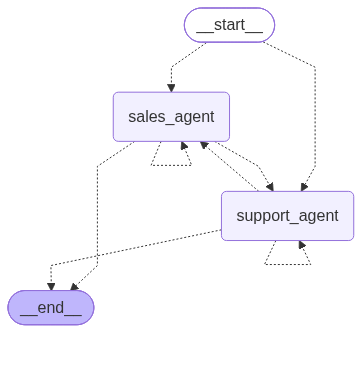

In [9]:
display(Image(handoff_graph.get_graph().draw_mermaid_png()))

### 실행

동일한 `thread_id`를 사용하면 Handoff 이후에도 현재 담당 Agent가 유지된다. 첫 번째 요청은 `invoke()`로 Sales Agent의 응답과 상태를 확인한다. 이어지는 기술 문의는 `subgraphs=True`, `stream_mode="updates"`로 실행하여 Support Agent로 이동하는 과정을 확인한다. 같은 Thread에서 기술 지원 후속 질문을 보내면 Support Agent부터 실행되어 대화를 이어간다. 이후 제품과 가격을 문의하여 Sales Agent로 돌아오는 과정도 확인한다.

In [10]:
config = {"configurable": {"thread_id": "customer-2"}}

first_state = handoff_graph.invoke(
    {
        "messages": [HumanMessage(content="AI 스피커 가격과 구매 방법을 알려줘.")],
        "active_agent": "sales_agent",
    },
    config=config,
)

print("Active agent:", first_state["active_agent"])
print("Final response:", first_state["messages"][-1].text)

Active agent: sales_agent
Final response: AI 스피커의 가격과 구매 방법을 안내해 드리겠습니다.

### 1. 주요 AI 스피커 제품 및 가격대
* **입문형 / 미니 사이즈** (예: Google Nest Mini, Kakao Mini 등)
  * **가격대:** 약 30,000원 ~ 60,000원
  * 간단한 음성 검색, 일정 관리, 음악 재생용으로 적합합니다.
* **표준형 / 디스플레이형** (예: Google Nest Hub, Apple HomePod mini 등)
  * **가격대:** 약 70,000원 ~ 150,000원
  * 화면이 내장되어 있어 영상 시청 및 스마트홈 제어가 더욱 편리합니다.
* **고음질 / 프리미엄형** (예: Apple HomePod, 고급 블루투스 연동 스피커 등)
  * **가격대:** 약 200,000원 ~ 400,000원 이상
  * 뛰어난 음질과 풍부한 사운드를 제공하며 스마트홈 매니저 기능이 강화되어 있습니다.

---

### 2. 구매 방법
1. **온라인 공식몰 및 오픈마켓**
   * 각 제조사 공식 브랜드스토어(네이버 스마트스토어, 쿠팡, 11번가 등)에서 구매 가능합니다.
2. **오프라인 가전 매장**
   * 하이마트, 일렉트로마트, 제조사 공식 플래그십 스토어 등에서 직접 청음 및 화면 체험 후 구매하실 수 있습니다.
3. **통신사 연계 상품**
   * 이용 중이신 통신사(SKT, KT, LGU+)의 인터넷/TV 결합 상품 가입 시 사은품 또는 할인 혜택으로 구매하실 수 있습니다.

원하시는 전용 브랜드나 주요 사용 목적(음악 감상, 스마트홈 제어, 아이 교육용 등)을 알려주시면 더욱 적합한 제품을 추천해 드릴 수 있습니다!


In [11]:
for namespace, update in handoff_graph.stream(
    {"messages": [HumanMessage(content="구매한 제품이 Wi-Fi에 연결되지 않아.")]},
    config=config,
    stream_mode="updates",
    subgraphs=True,
):
    graph_name = namespace[-1].split(":")[0] if namespace else "parent"
    node_name = next(iter(update))
    node_update = update[node_name]
    print(f"\n{graph_name} -> {node_name}")

    if isinstance(node_update, dict):
        messages = node_update.get("messages", [])
        if messages:
            message = messages[-1]
            if getattr(message, "tool_calls", None):
                tool_names = [call["name"] for call in message.tool_calls]
                print("Tool calls:", tool_names)
            if message.text:
                print(message.text)

second_state = handoff_graph.get_state(config).values
print("\nActive agent:", second_state["active_agent"])
print("Final response:", second_state["messages"][-1].text)


sales_agent -> model
Tool calls: ['transfer_to_support']

parent -> sales_agent
Support Agent로 전환했습니다.

support_agent -> model
제품이 Wi-Fi에 연결되지 않아 불편을 겪으셨군요. 아래 단계들을 차례대로 확인해 보시기 바랍니다.

### 1. Wi-Fi 주파수 대역 확인 (2.4GHz)
* 대부분의 AI 스피커 및 스마트 기기는 **2.4GHz Wi-Fi 대역**만 지원합니다.
* 공유기 이름(SSID) 중 **5GHz**가 아닌 **2.4GHz** 네트워크에 스마트폰과 스피커를 연결해 주세요.

### 2. 스마트폰과 기기 상태 확인
* 설정 시 **스마트폰의 블루투스와 Wi-Fi**가 모두 켜져 있는지 확인해 주세요.
* 스마트폰과 AI 스피커가 **동일한 Wi-Fi 네트워크**에 연결되어 있어야 합니다.

### 3. 공유기 및 기기 재부팅
1. AI 스피커의 전원 케이블을 뽑은 후 약 10초 뒤 다시 연결해 주세요.
2. Wi-Fi 공유기의 전원도 껐다가 다시 켜서 네트워크를 재설정해 주세요.

### 4. 기기 초기화 (Reset)
* 위의 방법으로 해결되지 않을 경우, 기기의 초기화(리셋) 버튼을 5~10초간 길게 눌러 제품을 공장 출하 상태로 돌린 후 전용 앱을 통해 다시 연결을 시도해 보세요.

만약 지속적으로 연결이 되지 않는다면, 사용 중이신 **AI 스피커의 정확한 모델명**을 알려주시면 상세한 해결 방법을 안내해 드리겠습니다.

parent -> support_agent
제품이 Wi-Fi에 연결되지 않아 불편을 겪으셨군요. 아래 단계들을 차례대로 확인해 보시기 바랍니다.

### 1. Wi-Fi 주파수 대역 확인 (2.4GHz)
* 대부분의 AI 스피커 및 스마트 기기는 **2.4GHz Wi-Fi 대역**만 지원합니다.
* 공유기 이름(SSID) 중 **5GHz**가 아닌 **2.4GHz** 네트워크에 스마트폰과 스피커를 연결해 주세요.


같은 `config`를 사용하고 `active_agent`를 다시 지정하지 않은 채 후속 질문을 보낸다. 실행 로그가 `support_agent`에서 시작하고, 응답 후에도 담당 Agent가 유지되는지 확인한다.

In [12]:
for namespace, update in handoff_graph.stream(
    {"messages": [HumanMessage(content="재부팅했는데도 Wi-Fi에 연결되지 않아. 다음에는 무엇을 확인해야 해?")]},
    config=config,
    stream_mode="updates",
    subgraphs=True,
):
    graph_name = namespace[-1].split(":")[0] if namespace else "parent"
    node_name = next(iter(update))
    node_update = update[node_name]
    print(f"\n{graph_name} -> {node_name}")

    if isinstance(node_update, dict):
        messages = node_update.get("messages", [])
        if messages:
            message = messages[-1]
            if getattr(message, "tool_calls", None):
                tool_names = [call["name"] for call in message.tool_calls]
                print("Tool calls:", tool_names)
            if message.text:
                print(message.text)

followup_state = handoff_graph.get_state(config).values
print("\nActive agent:", followup_state["active_agent"])
print("Final response:", followup_state["messages"][-1].text)


support_agent -> model
재부팅 후에도 연결되지 않는다면, 아래의 추가 항목들을 순서대로 점검해 보시는 것을 권장합니다.

---

### 1. Wi-Fi 주파수 대역 및 비번 확인 (가장 흔한 원인)
* **2.4GHz 전용 여부:** 스마트 기기 특성상 **5GHz Wi-Fi는 지원하지 않는 경우**가 많습니다. 공유기 설정에서 2.4GHz 네트워크 이름(SSID)에 연결했는지 다시 확인해 주세요.
* **비밀번호 특수문자:** Wi-Fi 비밀번호에 너무 복잡한 특수문자나 공백이 포함되어 있으면 인식 오류가 발생할 수 있습니다. (필요 시 영문+숫자 조합으로 변경 테스트)

### 2. 기기 강제 초기화 (Factory Reset)
* 기존 연결 정보 오류일 수 있으므로 기기를 완전히 초기화한 뒤 처음부터 재설정해야 합니다.
* **방법:** 기기 뒷면이나 하단의 **마이크 음소거 버튼** 또는 **전원/볼륨 버튼**을 10~15초 이상 길게 누르면 초기화 안내 음성이 나옵니다. (모델별로 버튼 조합이 다를 수 있습니다.)

### 3. 모바일 핫스팟(테더링) 테스트
* **목적:** 문제 원인이 '기기 자체 결함'인지 '자택 공유기 설정 문제'인지 구분하기 위함입니다.
1. 다른 스마트폰의 **모바일 핫스팟(2.4GHz)**을 켭니다.
2. AI 스피커를 핫스팟 Wi-Fi에 연결해 봅니다.
3. 핫스팟에 정상 연결된다면 스피커 기기는 정상이며, **자택 공유기 설정(보안/IP 할당 등)**의 문제일 가능성이 높습니다.

### 4. 공유기 보안 및 IP 설정 확인
* **MAC 주소 제한 / 보안 설정:** 공유기에 보안 필터링이 설정되어 있다면 새로운 기기 접속이 차단될 수 있습니다.
* **IP 할당 문제:** 공유기에 연결된 기기가 많아 IP가 부족한 경우 발생할 수 있으니, 공유기 관리자 페이지에서 DHCP 범위를 점검해 보세요.

---

모바일 핫스팟 테스트 결과나 **사용 중이신 AI 스피커 모델명**을 알려주시면, 해당 제

In [13]:
for namespace, update in handoff_graph.stream(
    {"messages": [HumanMessage(content="그럼 다른 색상도 있는지와 가격을 알려줘.")]},
    config=config,
    stream_mode="updates",
    subgraphs=True,
):
    graph_name = namespace[-1].split(":")[0] if namespace else "parent"
    node_name = next(iter(update))
    node_update = update[node_name]
    print(f"\n{graph_name} -> {node_name}")

    if isinstance(node_update, dict):
        messages = node_update.get("messages", [])
        if messages:
            message = messages[-1]
            if getattr(message, "tool_calls", None):
                tool_names = [call["name"] for call in message.tool_calls]
                print("Tool calls:", tool_names)
            if message.text:
                print(message.text)

third_state = handoff_graph.get_state(config).values
print("\nActive agent:", third_state["active_agent"])
print("Final response:", third_state["messages"][-1].text)


support_agent -> model
Tool calls: ['transfer_to_sales']

parent -> support_agent
Sales Agent로 전환했습니다.

sales_agent -> model
사용 중이시거나 관심을 두고 계신 특정 AI 스피커 모델명을 알려주시면 정확한 색상 라인업과 가격을 안내해 드릴 수 있습니다!

일반적으로 많이 찾으시는 주요 제품들의 색상 옵션과 가격대는 다음과 같습니다.

---

### 1. Apple HomePod / HomePod mini
* **HomePod mini** (약 120,000원 ~ 130,000원)
  * **색상:** 스페이스 그레이, 블루, 옐로, 오렌지, 화이트 (총 5가지)
* **HomePod 2세대** (약 380,000원 ~ 400,000원)
  * **색상:** 미드나이트, 화이트 (총 2가지)

### 2. Google Nest 시리즈
* **Google Nest Mini** (약 50,000원 ~ 60,000원)
  * **색상:** 차콜(Charcoal), 초크(Chalk) (국내 정발 기준)
* **Google Nest Hub 2세대** (약 110,000원 ~ 125,000원)
  * **색상:** 차콜, 초크

### 3. 카카오 / 네이버 클로바 스피커
* **카카오미니 / 카카오 프렌즈 스피커** (약 40,000원 ~ 70,000원)
  * **색상 및 디자인:** 라이언, 어피치 등 캐릭터 피규어 옵션 제공
* **네이버 클로바 램프 / 록** (약 80,000원 ~ 150,000원)
  * **색상:** 화이트, 베이지 등 모던한 컬러 중심

---

혹시 원하시는 특정 브랜드나 모델이 있으신가요? 말씀해 주시면 최저가 및 구매 혜택도 함께 확인해 드리겠습니다!

parent -> sales_agent
사용 중이시거나 관심을 두고 계신 특정 AI 스피커 모델명을 알려주시면 정확한 색상 라인업과 가격을 안내해 드릴 수 있습니다!

일반적으로 많이 찾

### 언제 사용할까

Router, Supervisor, Handoff는 요청을 분배하고 작업을 이어가는 대표적인 패턴이다. 서로 엄격히 구분할 필요는 없으며, 필요에 따라 함께 사용할 수 있다.

| 패턴 | 주요 역할 | 예시 |
| --- | --- | --- |
| Router | 요청을 받아 적절한 Agent에게 분배한다. | 문의를 분류해 판매 또는 기술 지원 Agent로 전달 |
| Supervisor | 작업을 위임하고, 중간 결과를 보며 다음 작업을 결정한다. | 조사 결과로 보고서를 작성하게 하고, 검토 결과에 따라 수정을 요청 |
| Handoff | 현재 Agent가 다른 Agent에게 담당권을 넘기고, 전환된 Agent가 대화를 이어간다. | 판매 상담 중 기술 지원으로 전환한 뒤 후속 질문도 Support Agent가 처리 |

Router는 요청을 분류하고 분배하는 단계에 초점을 둔다. 하나의 Agent를 선택할 수도 있고 여러 Agent에 작업을 나누어 결과를 모을 수도 있다. 새로운 사용자 요청이 오면 다시 실행할 수 있으며, 대화 기록을 참고해 분배할 수도 있다.

Supervisor는 전문가의 결과를 받아 다음 작업이 필요한지 판단한다. 조사 내용이 부족하면 추가 조사를 요청하고, 보고서에 수정 사항이 있으면 다시 작성을 맡기는 식으로 위임과 판단을 반복할 수 있다.

Handoff는 현재 담당자를 State에 저장한다. 이 예제에서는 Support Agent로 전환한 뒤 같은 Thread에서 후속 질문을 보내면 Support Agent부터 실행된다. 다시 Handoff가 일어나기 전까지 해당 Agent가 대화를 담당한다.

요청 분류와 분배가 중심이면 Router, 중간 결과에 따른 작업 조율이 중심이면 Supervisor, 여러 턴에 걸친 담당 유지와 전환이 중심이면 Handoff를 고려한다.